In [5]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import scipy.sparse as sp

print("Libraries loaded successfully")

Libraries loaded successfully


In [6]:
# Load trained model
with open("/content/drive/MyDrive/FactLens_Group9/data/logistic_regression_model.pkl", "rb") as f:
    model = pickle.load(f)

# Load vectorizer to get feature names
with open("/content/drive/MyDrive/FactLens_Group9/data/tfidf_vectorizer.pkl", "rb") as f:
    vectorizer = pickle.load(f)

print("Model loaded successfully")
print("Vectorizer loaded successfully")
print(f"Total features: {len(vectorizer.get_feature_names_out())}")

Model loaded successfully
Vectorizer loaded successfully
Total features: 50000


In [7]:
# Get feature names and coefficients
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

# Create a dataframe of words and their weights
coef_df = pd.DataFrame({
    "word": feature_names,
    "coefficient": coefficients
})

# Sort by coefficient value
coef_df = coef_df.sort_values("coefficient", ascending=False)

print(f"Total words with coefficients: {len(coef_df)}")
print(f"\nHighest coefficient: {coef_df['coefficient'].max():.4f}")
print(f"Lowest coefficient:  {coef_df['coefficient'].min():.4f}")

Total words with coefficients: 50000

Highest coefficient: 19.6045
Lowest coefficient:  -8.3712


In [8]:
# Top 20 words pushing toward FAKE
top_fake = coef_df.head(20)

print("TOP 20 FAKE NEWS INDICATORS:")
print("=" * 45)
for _, row in top_fake.iterrows():
    print(f"  {row['word']:30} {row['coefficient']:+.4f}")

TOP 20 FAKE NEWS INDICATORS:
  reuters                        +19.6045
  said                           +18.8562
  washington reuters             +8.5331
  washington                     +5.4185
  wednesday                      +5.0952
  president donald               +4.9875
  tuesday                        +4.9154
  thursday                       +4.3286
  friday                         +4.2024
  monday                         +4.0213
  reuters president              +3.8947
  minister                       +3.6081
  dont                           +3.5065
  representative                 +3.4187
  nov                            +3.4157
  im                             +3.3017
  said statement                 +3.2400
  obamas                         +3.0160
  told reuters                   +3.0091
  government                     +2.8627


In [9]:
# Top 20 words pushing toward REAL
top_real = coef_df.tail(20).sort_values("coefficient")

print("TOP 20 REAL NEWS INDICATORS:")
print("=" * 45)
for _, row in top_real.iterrows():
    print(f"  {row['word']:30} {row['coefficient']:+.4f}")

TOP 20 REAL NEWS INDICATORS:
  via                            -8.3712
  image                          -8.2651
  image via                      -5.0414
  gop                            -4.9063
  obama                          -4.8669
  hillary                        -4.5257
  even                           -4.5138
  like                           -4.2882
  mr                             -4.2726
  president trump                -4.2708
  american                       -4.2284
  america                        -3.8130
  know                           -3.6396
  video                          -3.6272
  president obama                -3.2770
  fact                           -3.2172
  rep                            -3.1519
  get                            -3.0599
  wire                           -3.0554
  really                         -2.9934


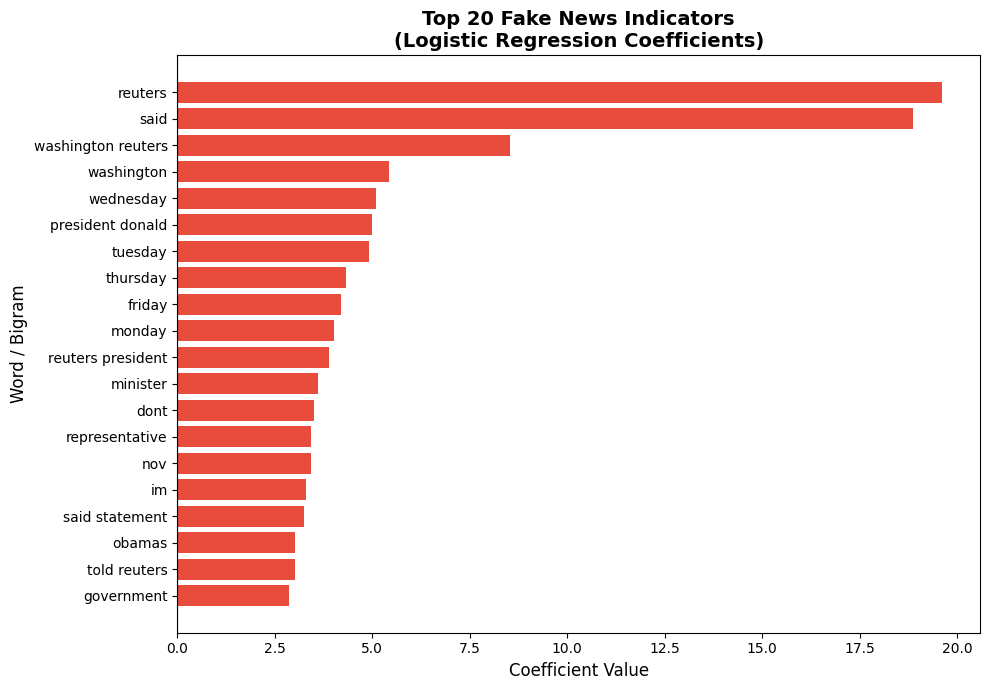

In [10]:
plt.figure(figsize=(10, 7))
colors = ["#E74C3C"] * 20
bars = plt.barh(top_fake["word"][::-1],
                top_fake["coefficient"][::-1],
                color=colors)
plt.title("Top 20 Fake News Indicators\n(Logistic Regression Coefficients)",
          fontsize=14, fontweight="bold")
plt.xlabel("Coefficient Value", fontsize=12)
plt.ylabel("Word / Bigram", fontsize=12)
plt.axvline(x=0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/FactLens_Group9/data/top_fake_words.png", dpi=150)
plt.show()

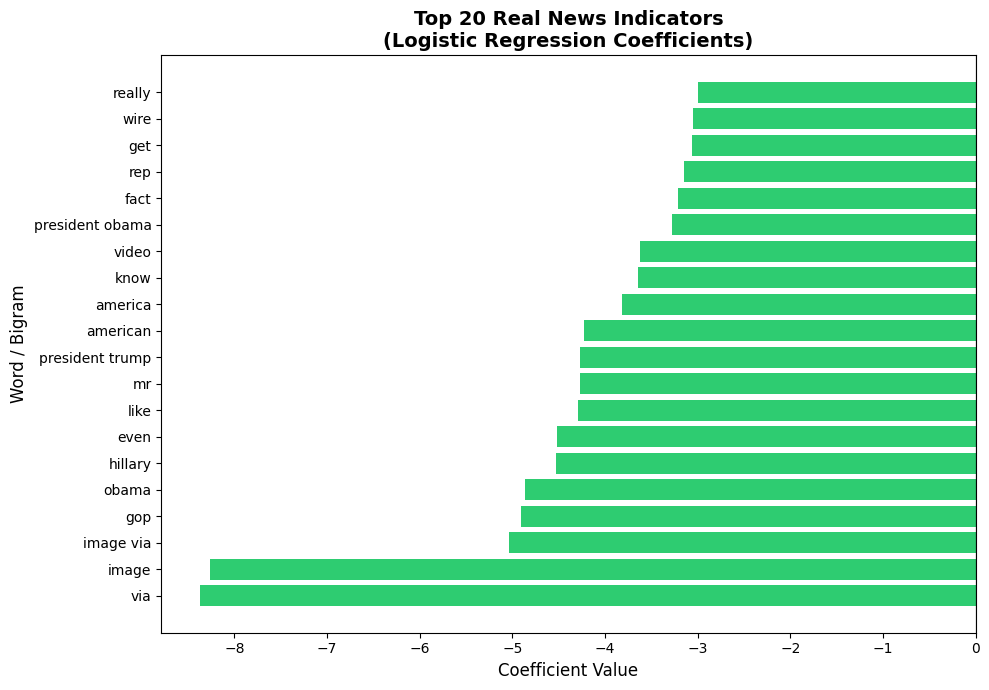

In [11]:
plt.figure(figsize=(10, 7))
colors = ["#2ECC71"] * 20
bars = plt.barh(top_real["word"],
                top_real["coefficient"],
                color=colors)
plt.title("Top 20 Real News Indicators\n(Logistic Regression Coefficients)",
          fontsize=14, fontweight="bold")
plt.xlabel("Coefficient Value", fontsize=12)
plt.ylabel("Word / Bigram", fontsize=12)
plt.axvline(x=0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/FactLens_Group9/data/top_real_words.png", dpi=150)
plt.show()

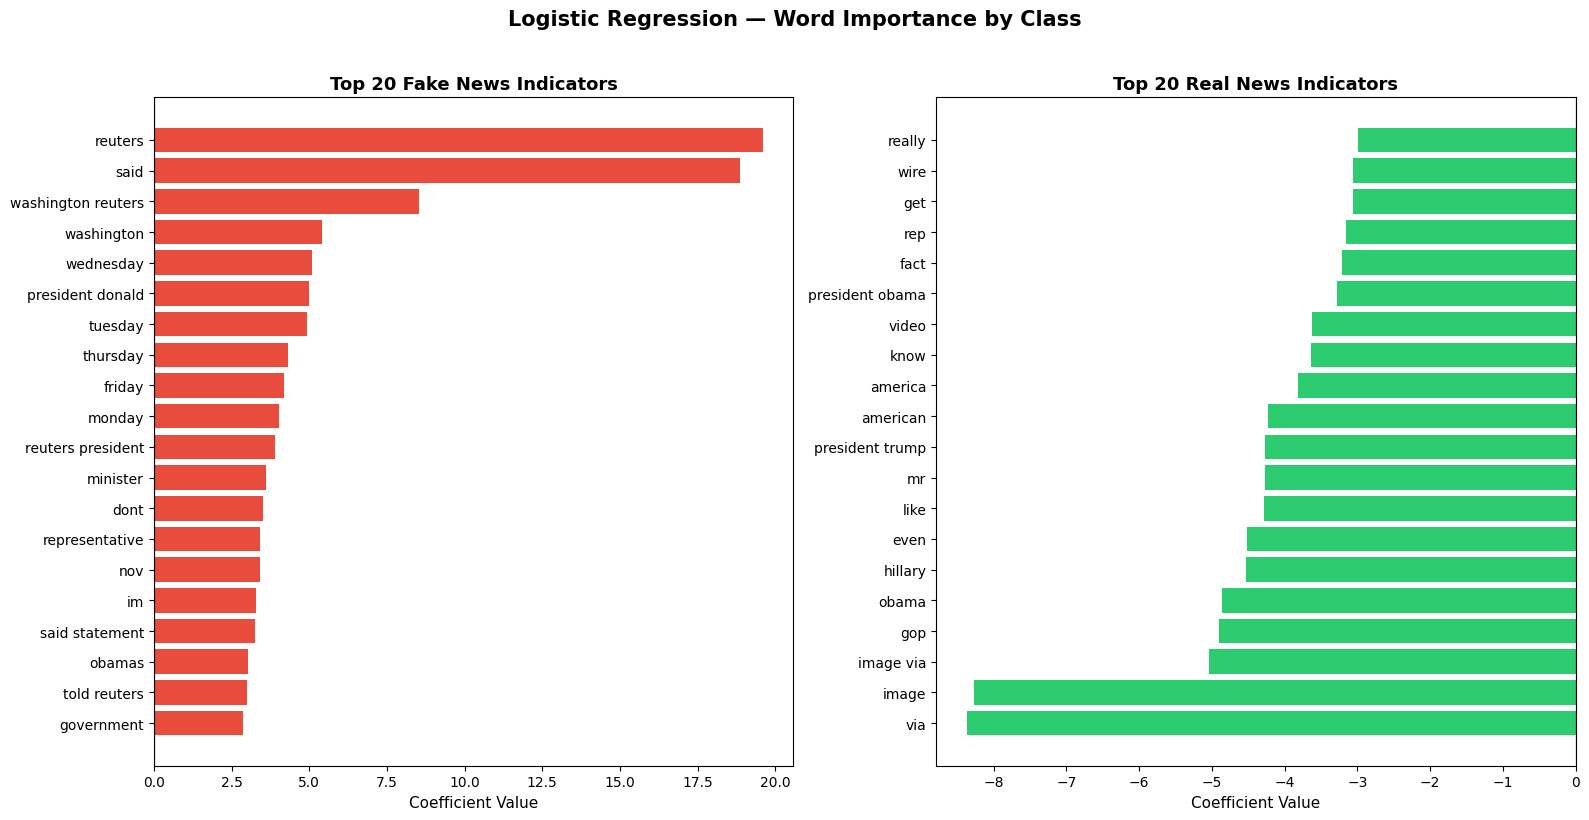

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Fake indicators - left chart
ax1.barh(top_fake["word"][::-1],
         top_fake["coefficient"][::-1],
         color="#E74C3C")
ax1.set_title("Top 20 Fake News Indicators",
              fontsize=13, fontweight="bold")
ax1.set_xlabel("Coefficient Value", fontsize=11)
ax1.axvline(x=0, color="black", linewidth=0.8)

# Real indicators - right chart
ax2.barh(top_real["word"],
         top_real["coefficient"],
         color="#2ECC71")
ax2.set_title("Top 20 Real News Indicators",
              fontsize=13, fontweight="bold")
ax2.set_xlabel("Coefficient Value", fontsize=11)
ax2.axvline(x=0, color="black", linewidth=0.8)

plt.suptitle("Logistic Regression — Word Importance by Class",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/FactLens_Group9/data/combined_word_importance.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [13]:
# Load test data and cleaned dataframe
X_test = sp.load_npz("/content/drive/MyDrive/FactLens_Group9/data/X_test.npz")
y_test = pd.read_csv("/content/drive/MyDrive/FactLens_Group9/data/y_test.csv")["label"]
df = pd.read_csv("/content/drive/MyDrive/FactLens_Group9/data/df_cleaned.csv")

# Pick the first fake article in the test set
fake_idx = y_test[y_test == "FAKE"].index[0]
article_vector = X_test[y_test.index.get_loc(fake_idx)]

# Get prediction and probability
pred = model.predict(article_vector)[0]
prob = model.predict_proba(article_vector)[0]

print(f"Article index: {fake_idx}")
print(f"Actual label:    {y_test.iloc[y_test.index.get_loc(fake_idx)]}")
print(f"Predicted label: {pred}")
print(f"Fake probability: {prob[0]:.2%}")
print(f"Real probability: {prob[1]:.2%}")

# Get the most influential words in this specific article
article_array = article_vector.toarray()[0]
nonzero_idx = article_array.nonzero()[0]

word_contributions = []
for idx in nonzero_idx:
    word = feature_names[idx]
    tfidf_score = article_array[idx]
    coef = coefficients[idx]
    contribution = tfidf_score * coef
    word_contributions.append((word, contribution))

word_contributions = sorted(word_contributions, key=lambda x: abs(x[1]), reverse=True)[:15]

print(f"\nTop 15 most influential words in this article:")
print("=" * 50)
for word, contribution in word_contributions:
    direction = "→ FAKE" if contribution > 0 else "→ REAL"
    print(f"  {word:30} {contribution:+.4f}  {direction}")

Article index: 0
Actual label:    FAKE
Predicted label: FAKE
Fake probability: 94.68%
Real probability: 5.32%

Top 15 most influential words in this article:
  said                           +0.3274  → FAKE
  sheriff                        -0.2758  → REAL
  obama                          -0.2628  → REAL
  drug                           +0.1820  → FAKE
  america                        -0.1464  → REAL
  via                            -0.1391  → REAL
  american                       -0.1366  → REAL
  going                          -0.1349  → REAL
  year                           +0.1121  → FAKE
  one                            -0.1095  → REAL
  inmate                         -0.1077  → REAL
  percent                        +0.0991  → FAKE
  told                           +0.0981  → FAKE
  tell                           -0.0961  → REAL
  claim                          -0.0925  → REAL
